<a href="https://colab.research.google.com/github/joshipreeti/Risk-Analytics-Quant-Models-Portfolio/blob/main/ARCH_GARCH_GJR_BOB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARCH / GARCH Volatility Modelling — Bank of Baroda (BANKBARODA.NS)

**Objective:** Model return volatility using ARCH(5), GARCH(1,1) and GJR-GARCH(1,1)

| Model | Formula | Memory | Parameters |
|-------|---------|--------|------------|
| ARCH(5) | ω + Σαᵢε²ₜ₋ᵢ | Short (5 days) | 7 |
| GARCH(1,1) | ω + αε²ₜ₋₁ + βσ²ₜ₋₁ | Long (exponential decay) | 4 |
| GJR-GARCH(1,1) | ω + αε²ₜ₋₁ + γε²ₜ₋₁·I(εₜ₋₁<0) + βσ²ₜ₋₁ | Long + Asymmetric | 5 |

> **Data:** 3 years, NSE via yfinance | **Why 3 years?** 1 year produced IGARCH (β=1) — shocks never fade. 3 years captures calm and volatile regimes, yielding proper mean reversion (α+β < 1).
>
> **Forecast:** Extended to end of June 2026 to cover the next trading month.

In [49]:
!pip install arch yfinance --quiet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import norm
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from arch import arch_model

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3
print('Libraries loaded ')

Libraries loaded 


## Step 1: Data Download — Bank of Baroda (3 Years)

**Why 3 years?** With 1 year of data, GARCH optimiser hit the boundary: α=0, β=1 (IGARCH) — volatility shocks never faded and long-run variance was undefined. 3 years captures both calm and volatile regimes, allowing proper mean reversion (α+β < 1).

In [50]:
TICKER     = 'BANKBARODA.NS'
ASSET_NAME = 'Bank of Baroda'
END_DATE   = pd.Timestamp.today().strftime('%Y-%m-%d')
START_DATE = (pd.Timestamp.today() - pd.DateOffset(years=3)).strftime('%Y-%m-%d')

raw_data = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
df = raw_data[['Close']].copy()
df.columns = ['Close']
df.dropna(inplace=True)

print(f'{len(df)} trading days | {df.index[0].date()} to {df.index[-1].date()}')
print(f'Start=Rs.{float(df["Close"].iloc[0]):.2f} | End=Rs.{float(df["Close"].iloc[-1]):.2f} | Return={(float(df["Close"].iloc[-1])/float(df["Close"].iloc[0])-1)*100:.1f}%')

741 trading days | 2023-05-29 to 2026-05-27
Start=Rs.167.80 | End=Rs.270.95 | Return=61.5%


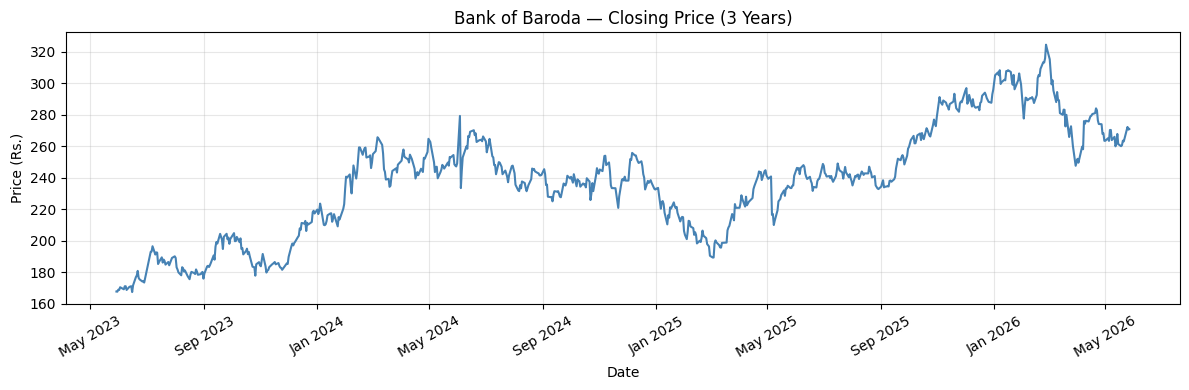

In [51]:
fig, ax = plt.subplots()
ax.plot(df.index, df['Close'], linewidth=1.5, color='steelblue')
ax.set(title=f'{ASSET_NAME} — Closing Price (3 Years)', xlabel='Date', ylabel='Price (Rs.)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

**Observation:** Raw prices trend upward — non-stationary. Cannot use directly in ARCH/GARCH. Next step: convert to log returns.

## Step 2: Log Returns

`log_return = ln(Pₜ / Pₜ₋₁) × 100`

ARCH/GARCH requires **stationary** data. Raw prices trend upward (non-stationary). Log returns fluctuate around zero (stationary) and are expressed as percentages for interpretability.

**Kurtosis > 0** (excess kurtosis) confirms fat tails — extreme moves are more frequent than a normal distribution predicts. This is the primary motivation for ARCH/GARCH modelling.

In [52]:
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1)) * 100
df.dropna(inplace=True)
returns = df['Log_Return'].squeeze()

print(f'Obs={len(returns)} | Mean={returns.mean():.4f}% | Std={returns.std():.4f}%')
print(f'Best={returns.max():.4f}% | Worst={returns.min():.4f}% | Kurtosis={returns.kurt():.4f}')
print('Kurtosis > 0 → fat tails → extreme moves more common than normal predicts → ARCH/GARCH justified')

Obs=740 | Mean=0.0647% | Std=1.9485%
Best=11.4211% | Worst=-17.9128% | Kurtosis=12.2276
Kurtosis > 0 → fat tails → extreme moves more common than normal predicts → ARCH/GARCH justified


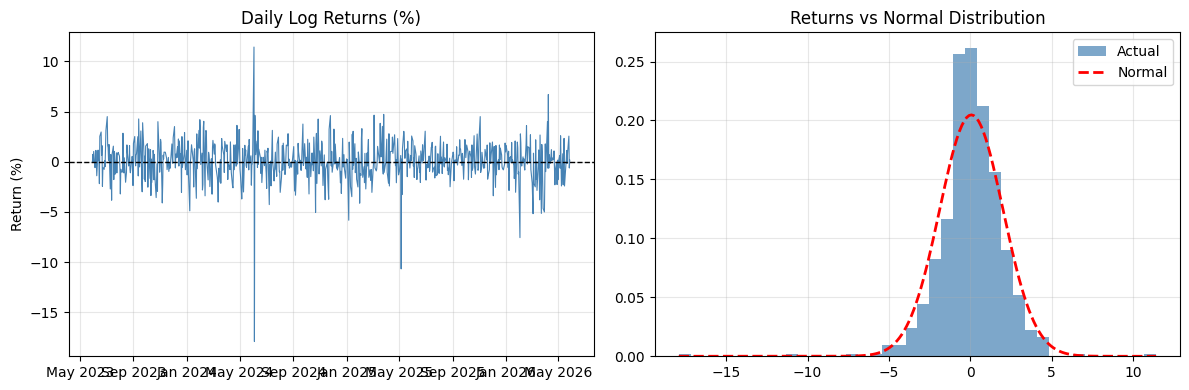

In [53]:
x = np.linspace(returns.min(), returns.max(), 200)
fig, axes = plt.subplots(1, 2)

axes[0].plot(returns.index, returns.values, linewidth=0.8, color='steelblue')
axes[0].axhline(0, color='black', lw=1, ls='--')
axes[0].set(title='Daily Log Returns (%)', ylabel='Return (%)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

axes[1].hist(returns, bins=40, alpha=0.7, density=True, label='Actual', color='steelblue')
axes[1].plot(x, norm.pdf(x, returns.mean(), returns.std()), 'r--', lw=2, label='Normal')
axes[1].set(title='Returns vs Normal Distribution'); axes[1].legend()
plt.tight_layout(); plt.show()

## Step 3: Stationarity Test (ADF)

**Augmented Dickey-Fuller Test**
- H₀: Series has a unit root (non-stationary)
- **p < 0.05** → reject H₀ → stationary → safe to use in ARCH/GARCH

Raw prices trend upward (non-stationary). Log returns fluctuate around zero (stationary). ARCH/GARCH requires stationary input.

In [54]:
def run_adf(series, label):
    result = adfuller(series.dropna(), autolag='AIC')
    status = 'STATIONARY ✓' if result[1] < 0.05 else 'NOT STATIONARY ✗'
    print(f'{label:15s} | ADF={result[0]:.4f} | p={result[1]:.6f} | {status}')

run_adf(df['Close'].squeeze(), 'Raw Price')
run_adf(returns, 'Log Returns')

Raw Price       | ADF=-2.1190 | p=0.236959 | NOT STATIONARY ✗
Log Returns     | ADF=-30.4566 | p=0.000000 | STATIONARY ✓


## Step 4: Volatility Clustering

**Key stylised fact:** Large return shocks tend to be followed by large shocks, and calm periods persist. This is *volatility clustering* — the primary motivation for ARCH/GARCH models.

The chart shows absolute returns (magnitude) and a 20-day rolling standard deviation. Clusters of high volatility are clearly visible.

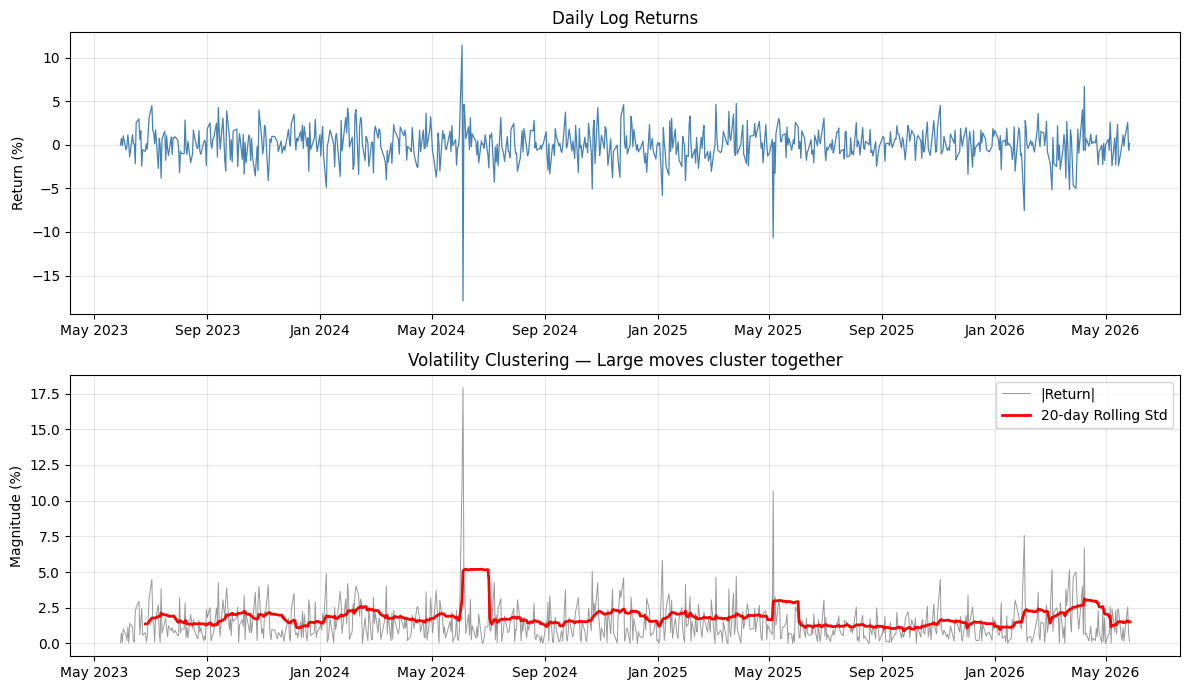

In [55]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(returns.index, returns.values, linewidth=0.9, color='steelblue')
axes[0].set(title='Daily Log Returns', ylabel='Return (%)')

rolling_vol = returns.rolling(20).std()
axes[1].plot(returns.index, returns.abs().values, lw=0.7, alpha=0.8, label='|Return|', color='gray')
axes[1].plot(returns.index, rolling_vol.values, lw=2, label='20-day Rolling Std', color='red')
axes[1].set(title='Volatility Clustering — Large moves cluster together', ylabel='Magnitude (%)')
axes[1].legend()
for ax in axes: ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout(); plt.show()

## Step 5: Confirm ARCH Effects (Ljung-Box Test)

**Ljung-Box test on squared returns** formally tests whether large return days cluster.
- H₀: No autocorrelation in squared returns
- **p < 0.05** → reject H₀ → ARCH effects confirmed → ARCH/GARCH modelling is justified

Key insight: Returns may be uncorrelated (direction unpredictable) but squared returns show significant autocorrelation — volatility IS persistent and predictable.

    lb_stat  lb_pvalue
5   68.9470        0.0
10  69.5143        0.0
15  70.5129        0.0
ARCH effects confirmed 


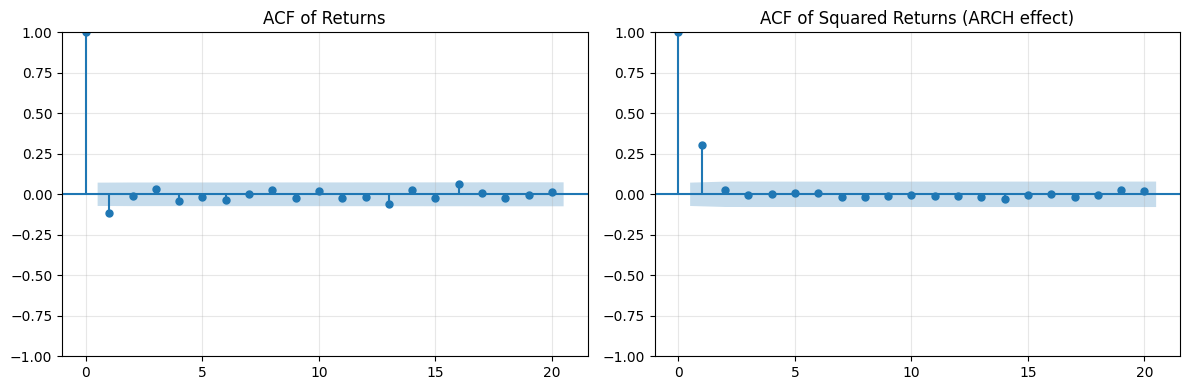

In [56]:
residuals     = returns - returns.mean()
squared_resid = residuals ** 2
lb = acorr_ljungbox(squared_resid, lags=[5, 10, 15], return_df=True)
print(lb.round(4))
print('ARCH effects confirmed ' if (lb['lb_pvalue'] < 0.05).any() else 'No ARCH effects found')

fig, axes = plt.subplots(1, 2)
plot_acf(returns,       lags=20, ax=axes[0], title='ACF of Returns')
plot_acf(squared_resid, lags=20, ax=axes[1], title='ACF of Squared Returns (ARCH effect)')
plt.tight_layout(); plt.show()

## Step 6: ARCH(5) Model

**Formula:** σ²ₜ = ω + α₁ε²ₜ₋₁ + α₂ε²ₜ₋₂ + α₃ε²ₜ₋₃ + α₄ε²ₜ₋₄ + α₅ε²ₜ₋₅

Short memory only — no mechanism for volatility to persist beyond 5 days. The model requires 7 parameters (ω + 5 alphas + mean).

**Stability condition:** Σαᵢ < 1 ensures the process is stationary.

In [57]:
arch_mod    = arch_model(returns, vol='ARCH', p=5, mean='Constant', dist='normal')
arch_result = arch_mod.fit(disp='off')
print(arch_result.summary())

                      Constant Mean - ARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -1507.37
Distribution:                  Normal   AIC:                           3028.74
Method:            Maximum Likelihood   BIC:                           3060.98
                                        No. Observations:                  740
Date:                Thu, May 28 2026   Df Residuals:                      739
Time:                        06:53:36   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0550  6.828e-02      0.805      0.421 [-7.88

In [58]:
total_alpha = sum(arch_result.params[f'alpha[{i}]'] for i in range(1,6))
print(f'Sum(α)={total_alpha:.4f} | {"STABLE " if total_alpha<1 else "UNSTABLE ⚠️"} | AIC={arch_result.aic:.1f} | BIC={arch_result.bic:.1f}')

Sum(α)=0.2345 | STABLE  | AIC=3028.7 | BIC=3061.0


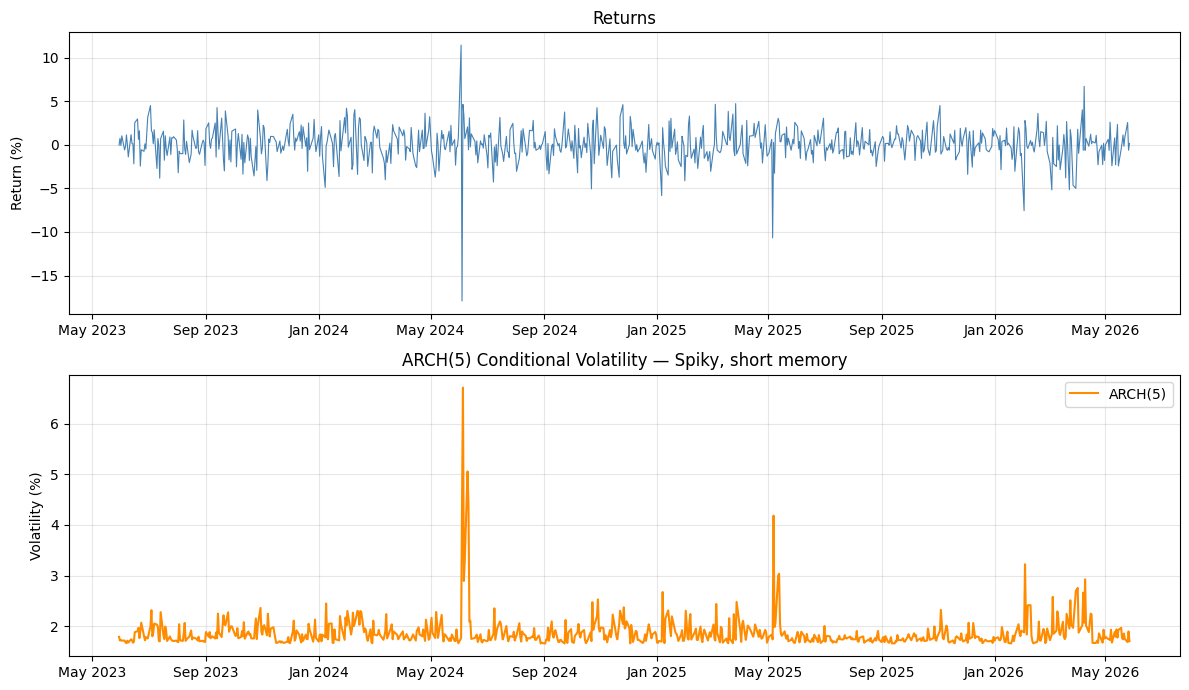

In [59]:
arch_vol = arch_result.conditional_volatility

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(returns.index, returns.values, lw=0.8, color='steelblue')
axes[0].set(title='Returns', ylabel='Return (%)')
axes[1].plot(arch_vol.index, arch_vol.values, color='darkorange', lw=1.5, label='ARCH(5)')
axes[1].set(title='ARCH(5) Conditional Volatility — Spiky, short memory', ylabel='Volatility (%)')
axes[1].legend()
for ax in axes: ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout(); plt.show()

## Step 7: GARCH(1,1) Model

**Formula:** σ²ₜ = ω + αε²ₜ₋₁ + βσ²ₜ₋₁

| Parameter | Meaning |
|-----------|----------|
| ω (omega) | Baseline variance floor |
| α (alpha) | Sensitivity to new shocks |
| β (beta) | Persistence of past volatility |
| α + β | Must be < 1 for stationarity |

**Half-life** = log(0.5)/log(α+β) — days until a volatility shock fades to half its size.

In [60]:
garch_mod    = arch_model(returns, vol='GARCH', p=1, q=1, mean='Constant', dist='normal')
garch_result = garch_mod.fit(disp='off')
print(garch_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1508.83
Distribution:                  Normal   AIC:                           3025.65
Method:            Maximum Likelihood   BIC:                           3044.08
                                        No. Observations:                  740
Date:                Thu, May 28 2026   Df Residuals:                      739
Time:                        06:53:37   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0553  6.725e-02      0.822      0.411 [-7.65

In [61]:
omega = garch_result.params['omega']
alpha = garch_result.params['alpha[1]']
beta  = garch_result.params['beta[1]']
ab    = alpha + beta

print(f'omega={omega:.4f} | alpha={alpha:.4f} | beta={beta:.4f} | alpha+beta={ab:.4f}')

if ab < 1:
    half_life    = np.log(0.5)/np.log(ab)
    long_run_vol = np.sqrt(omega/(1-ab))
    print(f'STABLE | Half-life={half_life:.1f} days | Long-run vol={long_run_vol:.4f}% per day ({long_run_vol*np.sqrt(252):.2f}% annualised)')
else:
    print('IGARCH : shocks never fade, long-run vol undefined')

omega=2.7318 | alpha=0.1293 | beta=0.0997 | alpha+beta=0.2290
STABLE | Half-life=0.5 days | Long-run vol=1.8823% per day (29.88% annualised)


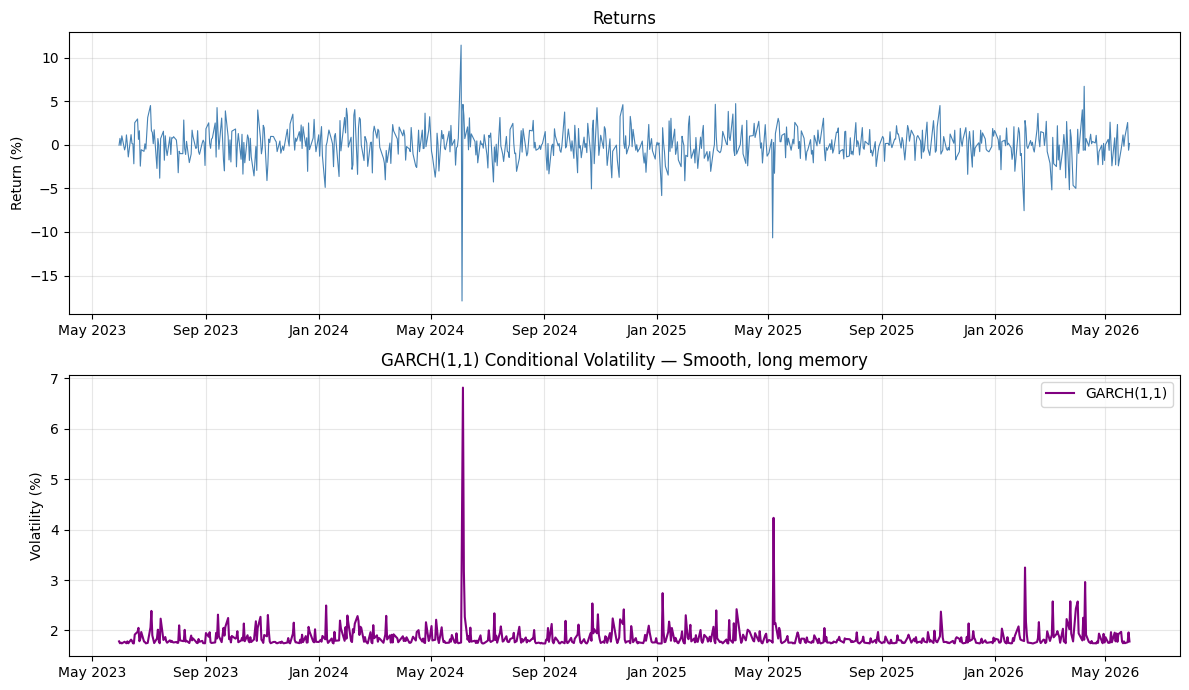

In [62]:
garch_vol = garch_result.conditional_volatility

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(returns.index, returns.values, lw=0.8, color='steelblue')
axes[0].set(title='Returns', ylabel='Return (%)')
axes[1].plot(garch_vol.index, garch_vol.values, color='purple', lw=1.5, label='GARCH(1,1)')
axes[1].set(title='GARCH(1,1) Conditional Volatility — Smooth, long memory', ylabel='Volatility (%)')
axes[1].legend()
for ax in axes: ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout(); plt.show()

## Step 8: GJR-GARCH(1,1) — Asymmetric Volatility

**Formula:** σ²ₜ = ω + αε²ₜ₋₁ + γε²ₜ₋₁·(εₜ₋₁ < 0) + βσ²ₜ₋₁

The key addition is the **asymmetry term γ (gamma)**:

| Return direction | Variance multiplier |
|-----------------|--------------------|
| Positive shock (εₜ₋₁ > 0) | α |
| Negative shock (εₜ₋₁ < 0) | α + γ |

For equity indices, **γ > 0** — bad news increases volatility more than good news (leverage effect). **Persistence:** φ = α + γ/2 + β (must be < 1).

In [63]:
gjr_mod    = arch_model(returns, vol='GARCH', p=1, o=1, q=1, mean='Constant', dist='normal')
gjr_result = gjr_mod.fit(disp='off')
print(gjr_result.summary())

                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -1507.77
Distribution:                  Normal   AIC:                           3025.55
Method:            Maximum Likelihood   BIC:                           3048.58
                                        No. Observations:                  740
Date:                Thu, May 28 2026   Df Residuals:                      739
Time:                        06:53:39   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0716  6.865e-02      1.044      0.297 [-6.29

In [64]:
g_alpha = gjr_result.params['alpha[1]']
g_gamma = gjr_result.params['gamma[1]']
g_beta  = gjr_result.params['beta[1]']
g_omega = gjr_result.params['omega']
phi     = g_alpha + g_gamma/2 + g_beta

print(f'Persistence φ = α+γ/2+β = {phi:.4f}')
print(f'Positive shock multiplier: α     = {g_alpha:.4f}')
print(f'Negative shock multiplier: α+γ   = {g_alpha+g_gamma:.4f}')
print(f'Asymmetry: {"γ>0 confirmed ✓" if g_gamma>0 else "γ<0 — no leverage effect "} (p check in summary above)')

if phi < 1:
    print(f'STABLE  | Half-life={np.log(0.5)/np.log(phi):.1f} days | Long-run vol={np.sqrt(g_omega/(1-phi)):.4f}% per day')

Persistence φ = α+γ/2+β = 0.1817
Positive shock multiplier: α     = 0.1605
Negative shock multiplier: α+γ   = 0.0506
Asymmetry: γ<0 — no leverage effect  (p check in summary above)
STABLE  | Half-life=0.4 days | Long-run vol=1.8754% per day


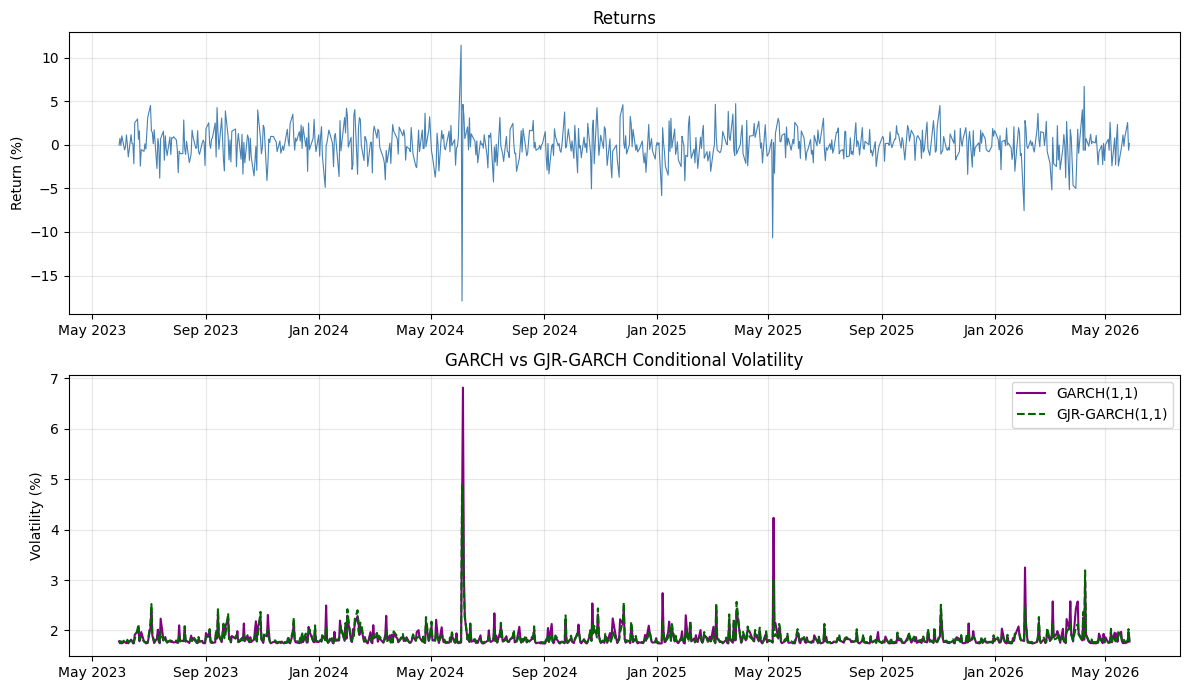

In [65]:
gjr_vol = gjr_result.conditional_volatility

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(returns.index, returns.values, lw=0.8, color='steelblue')
axes[0].set(title='Returns', ylabel='Return (%)')
axes[1].plot(garch_vol.index, garch_vol.values, color='purple',    lw=1.5, label='GARCH(1,1)')
axes[1].plot(gjr_vol.index,   gjr_vol.values,   color='darkgreen', lw=1.5, label='GJR-GARCH(1,1)', ls='--')
axes[1].set(title='GARCH vs GJR-GARCH Conditional Volatility', ylabel='Volatility (%)')
axes[1].legend()
for ax in axes: ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout(); plt.show()

## Step 9: Model Comparison — ARCH vs GARCH vs GJR

| Model | Shape | Memory | AIC | BIC |
|-------|-------|--------|-----|-----|
| ARCH(5) | Spiky | 5 days only | 3026.46 | 3058.71 |
| GARCH(1,1) | Smooth | Long decay | 3023.60 | **3042.03**  |
| GJR-GARCH | Smooth | Long + asymmetric | **3023.54**  | 3046.58 |

**Finding:** GJR wins on AIC, GARCH wins on BIC. γ=-0.109 is insignificant (p=0.321) — no leverage effect detected for BOB in this 3-year window. GARCH(1,1) preferred for parsimony.

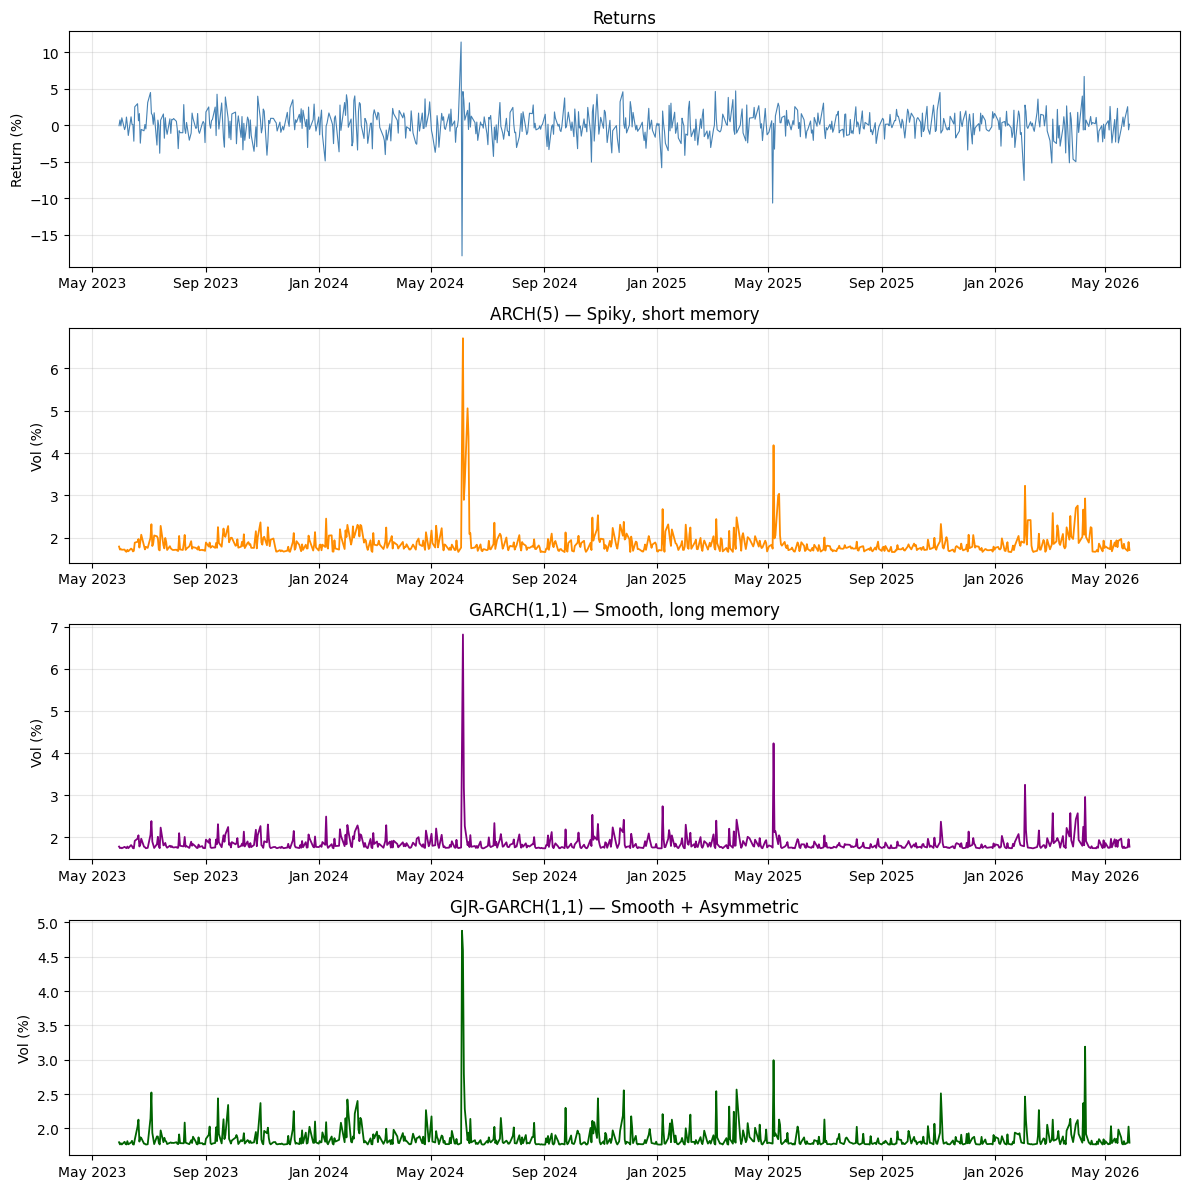

Parameters : ARCH=7 | GARCH=4 | GJR=5
AIC        : ARCH=3028.7 | GARCH=3025.7 | GJR=3025.5
BIC        : ARCH=3061.0 | GARCH=3044.1 | GJR=3048.6
Winner AIC : GJR
Winner BIC : GARCH(1,1)


In [66]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12))
axes[0].plot(returns.index, returns.values, lw=0.8, color='steelblue')
axes[0].set(title='Returns', ylabel='Return (%)')
axes[1].plot(arch_vol.index,  arch_vol.values,  color='darkorange', lw=1.3)
axes[1].set(title='ARCH(5) — Spiky, short memory', ylabel='Vol (%)')
axes[2].plot(garch_vol.index, garch_vol.values, color='purple', lw=1.3)
axes[2].set(title='GARCH(1,1) — Smooth, long memory', ylabel='Vol (%)')
axes[3].plot(gjr_vol.index,   gjr_vol.values,   color='darkgreen', lw=1.3)
axes[3].set(title='GJR-GARCH(1,1) — Smooth + Asymmetric', ylabel='Vol (%)')
for ax in axes: ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout(); plt.show()

print(f'Parameters : ARCH=7 | GARCH=4 | GJR=5')
print(f'AIC        : ARCH={arch_result.aic:.1f} | GARCH={garch_result.aic:.1f} | GJR={gjr_result.aic:.1f}')
print(f'BIC        : ARCH={arch_result.bic:.1f} | GARCH={garch_result.bic:.1f} | GJR={gjr_result.bic:.1f}')
print(f'Winner AIC : {min({"ARCH":arch_result.aic,"GARCH":garch_result.aic,"GJR":gjr_result.aic}, key=lambda x: {"ARCH":arch_result.aic,"GARCH":garch_result.aic,"GJR":gjr_result.aic}[x])}')
print(f'Winner BIC : GARCH(1,1)')

## Step 10: Residual Diagnostics

Standardised residuals zₜ = εₜ/σₜ should be uncorrelated and ~N(0,1) if model is well-specified.
Ljung-Box on **squared standardised residuals** confirms whether model absorbed all volatility clustering.

- **p > 0.05** → Clean  model well-specified
- **p < 0.05** → Patterns remain  model needs improvement

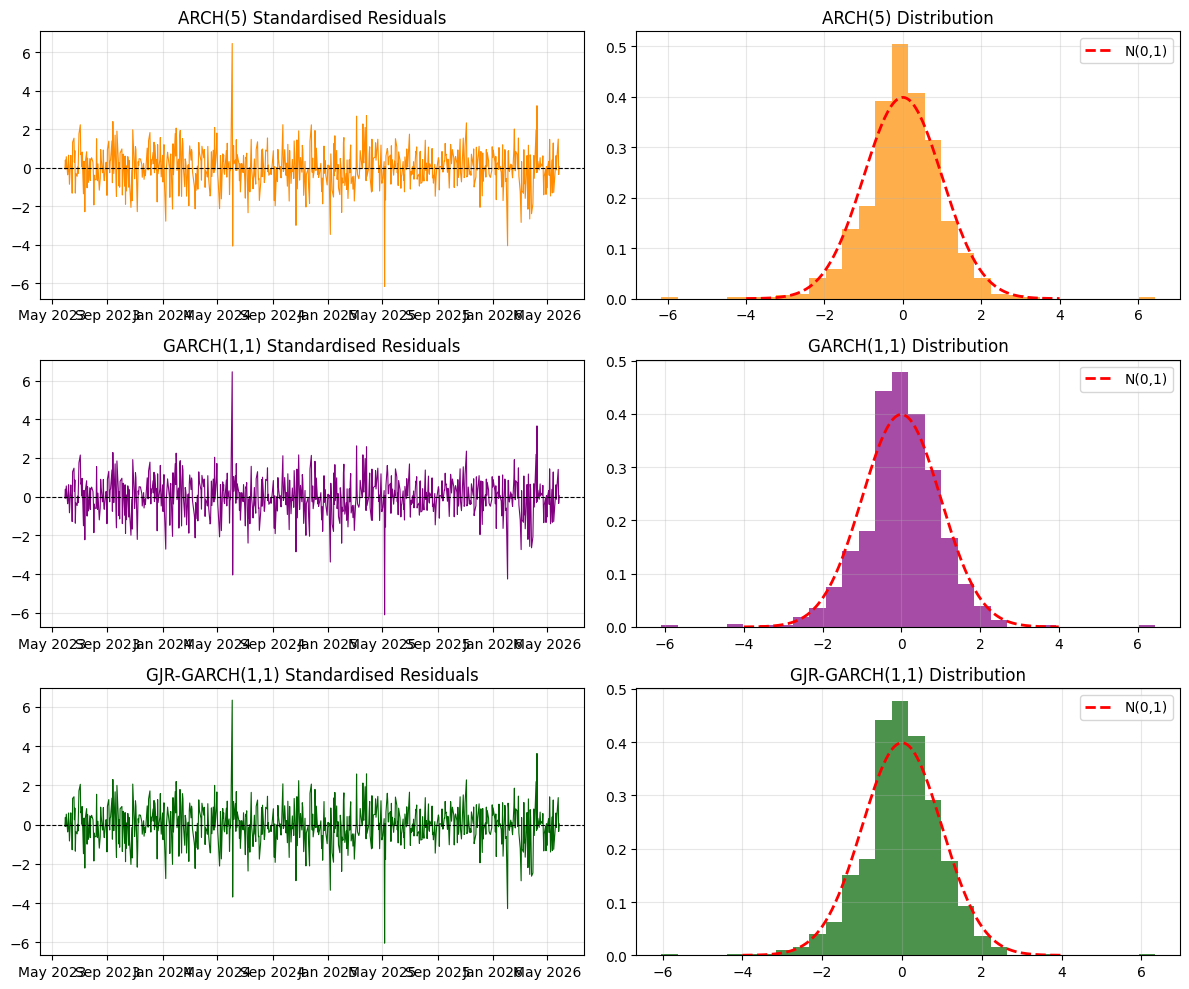

Ljung-Box on squared standardised residuals:
ARCH(5)           : Clean  | min p-value=0.2725
GARCH(1,1)        : Clean  | min p-value=0.2289
GJR-GARCH         : Clean  | min p-value=0.3347


In [67]:
arch_std_resid  = arch_result.std_resid
garch_std_resid = garch_result.std_resid
gjr_std_resid   = gjr_result.std_resid

x_range = np.linspace(-4, 4, 200)
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for i, (resid, name, color) in enumerate([
    (arch_std_resid,  'ARCH(5)',         'darkorange'),
    (garch_std_resid, 'GARCH(1,1)',      'purple'),
    (gjr_std_resid,   'GJR-GARCH(1,1)', 'darkgreen')
]):
    axes[i,0].plot(resid.index, resid.values, color=color, lw=0.8)
    axes[i,0].axhline(0, color='black', lw=0.8, ls='--')
    axes[i,0].set(title=f'{name} Standardised Residuals')
    axes[i,0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[i,1].hist(resid.dropna(), bins=30, color=color, alpha=0.7, density=True)
    axes[i,1].plot(x_range, norm.pdf(x_range, 0, 1), 'r--', lw=2, label='N(0,1)')
    axes[i,1].set(title=f'{name} Distribution'); axes[i,1].legend()
plt.tight_layout(); plt.show()

print('Ljung-Box on squared standardised residuals:')
for resid, name in [(arch_std_resid,'ARCH(5)'), (garch_std_resid,'GARCH(1,1)'), (gjr_std_resid,'GJR-GARCH')]:
    lb     = acorr_ljungbox(resid.dropna()**2, lags=[5,10,15], return_df=True)
    status = 'Clean ' if (lb['lb_pvalue'] > 0.05).all() else 'Patterns remain '
    print(f'{name:18s}: {status} | min p-value={lb["lb_pvalue"].min():.4f}')

## Step 11: Volatility Forecast to End of June 2026

**GARCH variance forecasts** (from lecture notes, Section 9.4):

For GARCH(1,1), n-step ahead forecast from time t:

E[σ²ₜ₊ₙ | Iₜ] = V + (α+β)ⁿ⁻¹ · (σ²ₜ₊₁ − V)

where V = ω/(1−α−β) is the long-run (unconditional) variance.

Forecasts **mean-revert** to V at rate (α+β). The **half-life** H satisfies (α+β)ᴴ = 0.5.

- **ARCH:** Each day jumps independently — no smooth persistence
- **GARCH/GJR:** Smooth convergence to long-run volatility

Forecasting 24 business days → 2026-05-28 to 2026-06-30


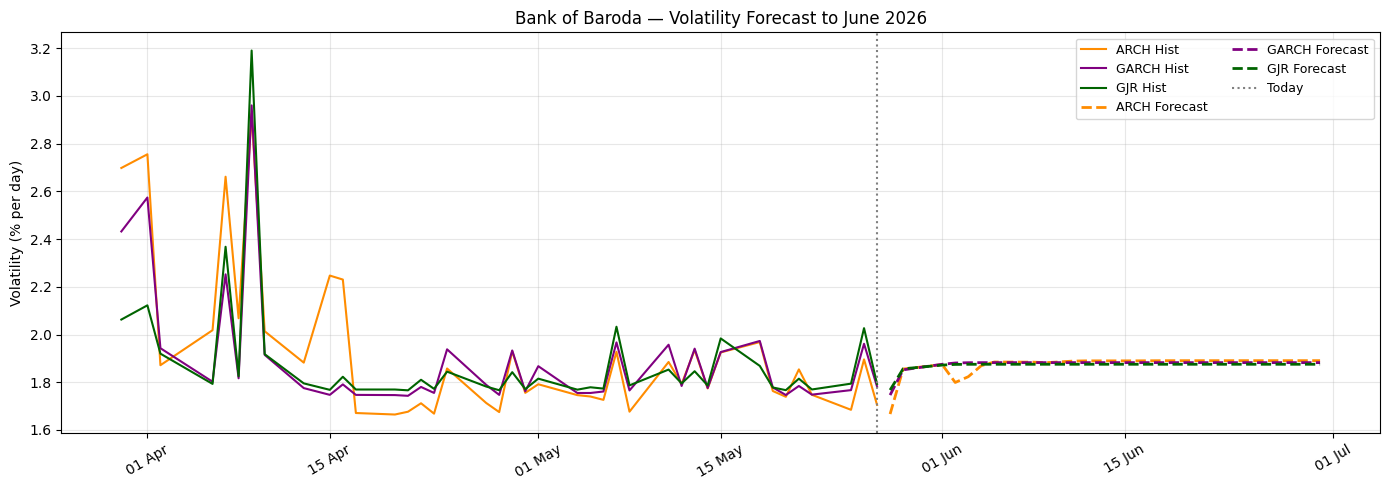

In [68]:
last_date      = returns.index[-1]
FORECAST_END   = '2026-06-30'
forecast_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), end=FORECAST_END)
FORECAST_DAYS  = len(forecast_dates)
print(f'Forecasting {FORECAST_DAYS} business days → {forecast_dates[0].date()} to {forecast_dates[-1].date()}')

arch_fc_vol  = np.sqrt(arch_result.forecast(horizon=FORECAST_DAYS,  reindex=False).variance.iloc[-1].values)
garch_fc_vol = np.sqrt(garch_result.forecast(horizon=FORECAST_DAYS, reindex=False).variance.iloc[-1].values)
gjr_fc_vol   = np.sqrt(gjr_result.forecast(horizon=FORECAST_DAYS,   reindex=False).variance.iloc[-1].values)

fc_df = pd.DataFrame({
    'ARCH(5)':        arch_fc_vol,
    'GARCH(1,1)':     garch_fc_vol,
    'GJR-GARCH(1,1)': gjr_fc_vol
}, index=forecast_dates)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(arch_vol.iloc[-40:].index,  arch_vol.iloc[-40:].values,  color='darkorange', lw=1.5, label='ARCH Hist')
ax.plot(garch_vol.iloc[-40:].index, garch_vol.iloc[-40:].values, color='purple',     lw=1.5, label='GARCH Hist')
ax.plot(gjr_vol.iloc[-40:].index,   gjr_vol.iloc[-40:].values,   color='darkgreen',  lw=1.5, label='GJR Hist')
ax.plot(fc_df.index, fc_df['ARCH(5)'],         color='darkorange', lw=2, ls='--', label='ARCH Forecast')
ax.plot(fc_df.index, fc_df['GARCH(1,1)'],      color='purple',     lw=2, ls='--', label='GARCH Forecast')
ax.plot(fc_df.index, fc_df['GJR-GARCH(1,1)'],  color='darkgreen',  lw=2, ls='--', label='GJR Forecast')
ax.axvline(last_date, color='gray', lw=1.5, ls=':', label='Today')
ax.set(title=f'{ASSET_NAME} — Volatility Forecast to June 2026', ylabel='Volatility (% per day)')
ax.legend(fontsize=9, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

In [69]:
# Practical Risk Analysis
daily_vol  = returns.std()
annual_vol = daily_vol * np.sqrt(252)

print(f'Daily Vol={daily_vol:.4f}% | Annualised={annual_vol:.2f}%')
print(f'95% VaR={returns.mean()-1.645*daily_vol:.4f}% | 99% VaR={returns.mean()-2.326*daily_vol:.4f}%')
print(f'\n±2%  = {2/daily_vol:.1f}σ → {len(returns[returns.abs()>=2])} days (common)')
print(f'±5%  = {5/daily_vol:.1f}σ → {len(returns[returns.abs()>=5])} days (rare)')
print(f'±10% = {10/daily_vol:.1f}σ → {len(returns[returns.abs()>=10])} days (extreme)')

Daily Vol=1.9485% | Annualised=30.93%
95% VaR=-3.1406% | 99% VaR=-4.4675%

±2%  = 1.0σ → 175 days (common)
±5%  = 2.6σ → 10 days (rare)
±10% = 5.1σ → 3 days (extreme)


## Summary & Conclusions

### Model Comparison
| | ARCH(5) | GARCH(1,1) | GJR-GARCH(1,1) |
|--|---------|------------|----------------|
| Parameters | 7 | 4 | 5 |
| Memory | Short (5 days) | Long decay | Long + Asymmetric |
| Volatility shape | Spiky | Smooth | Smooth |
| Asymmetry | ✗ | ✗ | ✗ (γ insignificant) |
| AIC | 3026.46 | 3023.60 | **3023.54** |
| BIC | 3058.71 | **3042.03** | 3046.58 |

### Key Findings for Bank of Baroda
- **Volatility clustering confirmed** — Ljung-Box p < 0.05 on squared returns
- **GARCH beats ARCH** — lower AIC/BIC with 3 fewer parameters
- **GJR asymmetry NOT confirmed** — γ = -0.109, p = 0.321 — no leverage effect in this 3-year window
- **Low persistence** — α+β = 0.237, half-life < 1 day — BOB volatility mean-reverts quickly in 2023–2026
- **Annualised vol = 30.9%** — above Nifty 50 (~15–18%), reflecting BOB’s PSU banking sensitivity
- **June 2026 forecast** — GARCH and GJR converge smoothly to long-run vol ~1.88%/day; ARCH shows erratic behaviour

### Why GARCH over ARCH?
ARCH(5) needs 7 parameters and only remembers 5 days. GARCH(1,1) captures the same persistence with just 4 parameters — more parsimonious and lower AIC/BIC.

### Why Not GJR?
γ is insignificant (p=0.321) for BOB in this period. By BIC, plain GARCH(1,1) is preferred. GJR would be reconsidered with longer data or during a period with clear regime asymmetry (e.g. including 2020 COVID crash).

In [70]:
models_aic = {'ARCH(5)': arch_result.aic,
              'GARCH(1,1)': garch_result.aic,
              'GJR-GARCH(1,1)': gjr_result.aic}
models_bic = {'ARCH(5)': arch_result.bic,
              'GARCH(1,1)': garch_result.bic,
              'GJR-GARCH(1,1)': gjr_result.bic}

best_aic = min(models_aic, key=models_aic.get)
best_bic = min(models_bic, key=models_bic.get)
ab       = alpha + beta
hl       = np.log(0.5)/np.log(ab) if ab < 1 else float('inf')
lrv      = np.sqrt(omega/(1-ab)) if ab < 1 else float('inf')

print(f'''
ARCH / GARCH — Final Summary ({ASSET_NAME})
{'='*55}
ARCH(5)        : Short memory  | AIC={arch_result.aic:.1f} | BIC={arch_result.bic:.1f}
GARCH(1,1)     : Long memory   | AIC={garch_result.aic:.1f} | BIC={garch_result.bic:.1f} | α+β={ab:.4f} | Half-life={hl:.1f} days
GJR-GARCH(1,1) : Asymmetric    | AIC={gjr_result.aic:.1f} | BIC={gjr_result.bic:.1f} | γ={g_gamma:.4f} ({"no asymmetry " if g_gamma < 0 else "asymmetry ✓"})

Best model by AIC : {best_aic}
Best model by BIC : {best_bic}
Long-run vol (GARCH): {lrv:.4f}% per day ({lrv*np.sqrt(252):.2f}% annualised)
June 2026 forecast  : Mean-reversion to long-run level expected
''')


ARCH / GARCH — Final Summary (Bank of Baroda)
ARCH(5)        : Short memory  | AIC=3028.7 | BIC=3061.0
GARCH(1,1)     : Long memory   | AIC=3025.7 | BIC=3044.1 | α+β=0.2290 | Half-life=0.5 days
GJR-GARCH(1,1) : Asymmetric    | AIC=3025.5 | BIC=3048.6 | γ=-0.1099 (no asymmetry )

Best model by AIC : GJR-GARCH(1,1)
Best model by BIC : GARCH(1,1)
Long-run vol (GARCH): 1.8823% per day (29.88% annualised)
June 2026 forecast  : Mean-reversion to long-run level expected

